# FTL in SR

This document explores the idea of faster than light (FTL) travel through the lens of the special theory of relativity (SR).

Consider a scenario where we have three different bodies moving in an inertial reference frame $S_1$, one of which is FTL. The worldlines of the bodies are:

$$
x_1(t) = 0
\quad\quad
x_2(t) = 0.95 c t
\quad\quad
x_3(t) = 1.2 c t
$$

So their velocities are:

$$
\dot x_1 = 0
\quad\quad
\dot x_2 = 0.95 c
\quad\quad
\dot x_3 = 1.2 c
$$

Since $|\dot x_3| > c$, body 3 is FTL. The other two are slower than light (STL).

Let's draw a spacetime diagram of the situation. I'll use units such that $c = 1$. Feel free to skip the code--reading it is not necessary to grasp the concepts.

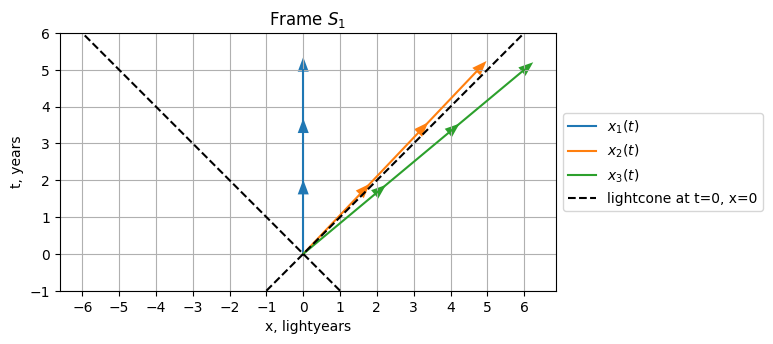

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

c = 1

def plot_lightcone(t_center, x_center, t_limit_past, t_limit_future, c=c):
    t = t_center + np.array([t_limit_past, t_limit_future])
    x_pos = x_center + c * t
    x_neg = x_center - c * t
    plt.plot(
        np.concat([x_pos, [None], x_neg]),
        np.concat([t, [None], t]),
        linestyle='--',
        color='black',
        label=f"lightcone at t={t_center:.02g}, x={x_center:.02g}")

def draw_arrow_along_worldline(t, x, color_idx, location_proportion=0.5, arrow_scale=1):
    location = int(location_proportion * (len(t) - 2))
    mid_dx = x[location + 1] - x[location]
    mid_dt = t[location + 1] - t[location]
    plt.arrow(
        x[location], t[location],
        mid_dx / 1e10, mid_dt / 1e10,
        head_width=0.3 * arrow_scale, head_length=0.4 * arrow_scale, lw=0, shape='full',
        color=f'C{color_idx}')

def plot_worldlines(*worldlines, t_limit_past=None, t_limit_future=None, x_limit_left=None, x_limit_right=None, grid_interval=1, title=None, arrow_scale=1):
    for color_idx, (t, x, label) in enumerate(worldlines):
        plt.plot(x, t, label=label, color=f"C{color_idx}")
        # Draw a few arrows along the worldline to indicate direction of travel
        draw_arrow_along_worldline(t, x, color_idx, arrow_scale=arrow_scale, location_proportion=0.333)
        draw_arrow_along_worldline(t, x, color_idx, arrow_scale=arrow_scale, location_proportion=0.666)
        draw_arrow_along_worldline(t, x, color_idx, arrow_scale=arrow_scale, location_proportion=1)

    plot_lightcone(
        0, 0,
        t_limit_past=-10 if t_limit_past is None else t_limit_past,
        t_limit_future=10 if t_limit_future is None else t_limit_future,
    )
    plt.xlabel('x, lightyears')
    plt.ylabel('t, years')
    plt.axis('square')
    plt.ylim(t_limit_past, t_limit_future)
    plt.xlim(x_limit_left, x_limit_right)
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MultipleLocator(grid_interval))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(grid_interval))
    plt.grid()
    plt.title(title)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

t_S1 = np.linspace(0, 5, 100)
x1_S1 = 0 * t_S1
x2_S1 = 0.95 * c * t_S1
x3_S1 = 1.2 * c * t_S1

plot_worldlines(
    (t_S1, x1_S1, "$x_1(t)$"),
    (t_S1, x2_S1, "$x_2(t)$"),
    (t_S1, x3_S1, "$x_3(t)$"),
    t_limit_past=-1,
    t_limit_future=6,
    title='Frame $S_1$',
)

plt.show()


The arrows along the worldlines indicate the body's direction of travel through spacetime.

The angle of a worldline with respect to the time axis ($x=0$) is determined by the body's velocity. The two lines of the lightcone are angled by 45 degrees away from the plot's time axis, because a ray of light travels one lightyear in one year.

Since body 3 is FTL, its angle from the time axis is greater than that of the lightcone, because for every year, it travels more than one lightyear.

Bodies 1 and 2 are STL, so their angles from the time axis are less than that of the lightcone, because for every year, they travel less than one lightyear. Body 1 doesn't travel at all, so it is completely parallel to the time axis.

Notice also that the angle between $x_2(t)$ and the lightcone is very small, since body 2 is only 5% less than the speed of light. Importantly (and we'll see why soon), this angle is smaller than that between body 3 and the lightcone, since body 3 is traveling 20% more than the speed of light.

Now I want to see what this scenario looks like in a frame where body 2 is stationary. To find out, we can use theLorentz transformation:

$$
t' = \frac{t - v x / c^2}{\sqrt{1 - (v / c)^2}}
\quad\quad
x' = \frac{x - v t}{\sqrt{1 - (v / c)^2}}
$$

To transform an entire worldline, we can think of the worldline is a set of events, $(t, x(t))$. We can apply the transformation to each of these events to get their coordinates $(t', x'(t'))$ in another reference frame.

If we use $v = \dot x_2 = 0.95 c$, we'll obtain the worldlines as measured in a frame, $S_2$, in which body 2 is stationary.

In [97]:
def lorentz_transform(t, x, v_boost, c=c):
    lorentz_factor = (1 - (v_boost / c)**2)**0.5
    t_ = (t - (v_boost * x / c**2)) / lorentz_factor
    x_ = (x - (v_boost * t)) / lorentz_factor
    return t_, x_

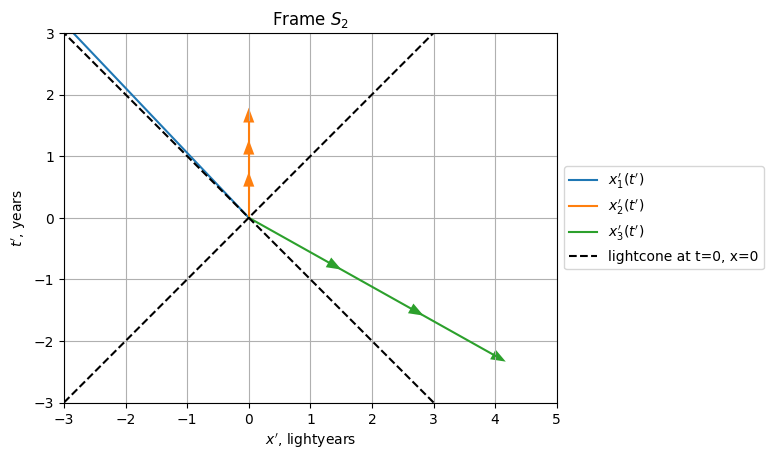

In [100]:
v_boost = 0.95 * c

t1_S2, x1_S2 = lorentz_transform(t_S1, x1_S1, v_boost)
t2_S2, x2_S2 = lorentz_transform(t_S1, x2_S1, v_boost)
t3_S2, x3_S2 = lorentz_transform(t_S1, x3_S1, v_boost)

plot_worldlines(
    (t1_S2, x1_S2, "$x_1'(t')$"),
    (t2_S2, x2_S2, "$x_2'(t')$"),
    (t3_S2, x3_S2, "$x_3'(t')$"),
    t_limit_past=-3,
    t_limit_future=3,
    x_limit_left=-3,
    x_limit_right=5,
    title='Frame $S_2$',
    arrow_scale=0.6,
)
plt.xlabel("$x'$, lightyears")
plt.ylabel("$t'$, years")

plt.show()

Surprisingly, body 3 is moving backward in time in this frame. This is indicated by the fact that the arrows along $x'_3(t')$ are pointing downward.

Let's quickly check what the Lorentz velocity addition formula says the velocity of body 3 should be in frame $S_2$, to help verify the above calculation.

$$
\dot x' = \frac{\dot x - v}{1 - \dot x v / c^2}
$$

In [99]:
x_dot = 1.2 * c
v_boost = 0.95 *c

x_dot_ = (x_dot - v_boost) / (1 - x_dot * v_boost / c**2)
x_dot_

-1.785714285714287

So in frame $S_1$ body 3 is moving at velocity $\dot x = 1.2 c$, and in frame $S_2$ it's moving at velocity $\dot x' \approx -1.78 c$. We can see in the above graph, as time increases, body 3 does indeed move to the left as time increases--it moves slightly less than two squares to the left for every one square it moves upward.

But again, body 3 is moving backward in time. The temporal order of the events in its worldline has been reversed. See that in frame $S_1$, the event at the origin was _before_ all the other events we plotted for body 3, but in frame $S_2$, the event at the origin is _after_ all the other events. And remember, we're talking about the same events in both frames. The events have different coordinates in different frames, i.e. when using different sets of basis vectors, but the events themselves are the same in both frames.

This is a really bizarre thing.

But is there any trouble with this result? Yes, there seems to be some trouble.

Let's assume that all of the bodies we're talking about can be normal matter, interacting with each other as normal matter does. For instance, the bodies could be spaceships with people on them, and they could send each other messages with light signals when they pass near each other. We can use FTL to send a message backward in time.

Look again at frame $S_2$ above. Let's say body 3 picks up a message from body 2 at the origin, $t'=0, x'=0$. Then body 3 goes backward in time at velocity $-1.78 c$, moving to the right on the plot. Now imagine that after some (negative) time, body 3 passes by a fourth body which is also going backward in time, but in the opposite spatial direction, with velocity $1.78 c$. Body 3 hands the message to body 4. Then body 4 continues to move to the left while going backward in time. Once body 4 reaches $x'=0$, it passes by body 2 and hands the message over, at some time $t' < 0$.

Notice, body 2 sends out a message at time $t' = 0$ and receives that same message at an earlier time $t' < 0$.

FTL in SR seems to enable sending messages backward in time, so that a body can be causally influenced by an event in its future light cone. Likewise, a body can causally influence an event in its past light cone.

Does this mean that FTL and SR are not logically compatible? I'm not sure.